In [1]:
import pandas as pd
import geopandas as gpd
import plotly.express as px
import os

#show me all the columns
pd.set_option('display.max_columns', None)

## Importing, inspecting and visualizing geo data

Helpful Indianapolis codes:
- Indiana is state fips 18
- Indianapolis is in Marion County, which is county fips 18097.

Where to download/find these GIS files for your state!
- **Schools:** [The NCES EDGE open data portal](https://data-nces.opendata.arcgis.com/) contains all sorts of helpful data, including school locations.
- **Neighborhoods:** check your city GIS site
- **Toxic Release Inventory:** Multiple years and states [available here](https://www.epa.gov/toxics-release-inventory-tri-program/tri-basic-data-files-calendar-years-1987-present)
- **Census Tigerline URLs:** [pick your vintage here](https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html), then click FTP Archive and navigate to the shapefile you need.

In [2]:
#establish your basepath so you don't need to keep typing it
gis_base = '../GIS'

#importing shapefiles and geojson
schools = gpd.read_file(f'{gis_base}/nces-in-schools.geojson')

#importing from zip
hoods = gpd.read_file(f'{gis_base}/Indy_Neighborhoods.zip')

#importing from url
tracts = gpd.read_file('https://www2.census.gov/geo/tiger/TIGER2024/TRACT/tl_2024_18_tract.zip')

#importing points from csv
tri = pd.read_csv(f'{gis_base}/epa-tri-2024-in.csv')
tri = gpd.GeoDataFrame(tri, geometry=gpd.points_from_xy(tri['13. LONGITUDE'], tri['12. LATITUDE']))

In [3]:
#exploring geodata is just like exploring any other dataframe
print('School count:',len(schools))
print(schools.dtypes)
display(schools.head())

#look the geometry!
print(schools.geometry)

#we can get the projection real quick too
print('Coordinate reference system:',schools.crs)

School count: 1928
OBJECTID         int32
NCESSCH            str
LEAID              str
NAME               str
OPSTFIPS           str
STREET             str
CITY               str
STATE              str
ZIP                str
STFIP              str
CNTY               str
NMCNTY             str
LOCALE             str
LAT            float64
LON            float64
CBSA               str
NMCBSA             str
CBSATYPE           str
CSA                str
NMCSA              str
CD                 str
SLDL               str
SLDU               str
SCHOOLYEAR         str
geometry      geometry
dtype: object


,OBJECTID,NCESSCH,LEAID,NAME,OPSTFIPS,STREET,CITY,STATE,ZIP,STFIP,CNTY,NMCNTY,LOCALE,LAT,LON,CBSA,NMCBSA,CBSATYPE,CSA,NMCSA,CD,SLDL,SLDU,SCHOOLYEAR,geometry
0,31784,180000802090,1800008,White River Valley Elementary Sch,18,484 W Main St,Worthington,IN,47471,18,18055,Greene County,42,39.119400,-86.986200,N,N,0,N,N,1808,18045,18039,2024-2025,POINT (-86.9862 39.1194)
1,31785,180000802302,1800008,White River Valley High School,18,5644 W SR 54,Switz City,IN,47465,18,18055,Greene County,42,39.035700,-87.047100,N,N,0,N,N,1808,18045,18039,2024-2025,POINT (-87.0471 39.0357)
2,31786,180000802304,1800008,White River Valley Middle School,18,2926 S SR 67,Lyons,IN,47443,18,18055,Greene County,42,38.978051,-87.100439,N,N,0,N,N,1808,18045,18039,2024-2025,POINT (-87.10044 38.97805)
3,31787,180000900115,1800009,Blue River Career Programs,18,801 St. Joseph Street,Shelbyville,IN,46176,18,18145,Shelby County,32,39.511431,-85.788646,26900,"Indianapolis-Carmel-Greenwood, IN",1,294,"Indianapolis-Carmel-Muncie, IN",1806,18073,18028,2024-2025,POINT (-85.78865 39.51143)
4,31788,180001002628,1800010,Greater Randolph Interlocal Coop,18,325 S Oak St - Suite 301,Winchester,IN,47394,18,18135,Randolph County,32,40.169441,-84.972984,N,N,0,N,N,1803,18033,18026,2024-2025,POINT (-84.97298 40.16944)


0         POINT (-86.9862 39.1194)
1         POINT (-87.0471 39.0357)
2       POINT (-87.10044 38.97805)
3       POINT (-85.78865 39.51143)
4       POINT (-84.97298 40.16944)
                   ...            
1923    POINT (-86.19284 39.84611)
1924    POINT (-86.18186 39.78673)
1925    POINT (-87.37595 39.46423)
1926     POINT (-87.67734 37.9643)
1927    POINT (-87.49073 37.96131)
Name: geometry, Length: 1928, dtype: geometry
Coordinate reference system: EPSG:4326


In [4]:
#now you try looking at the other geodataframes crs

Cam is gonna talk about projects here for a minute. They're important friends.

<Axes: >

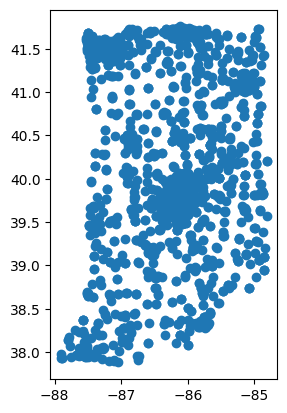

In [5]:
#quick viz
schools.plot()

## Finding hidden ARC data
Have you ever come across some really great geo data on a city's website but there's no download button? If it's an ARCGIS site you might be able to access the data by going through the backend!

Let's demo that now. If you're coming back to this later, here's a video of how to find and download ARCGIS data: https://www.youtube.com/watch?v=bqSBfOTTGwU

In [6]:
#let's load the crime data we just downloaded from the Indy PD's ARCGIS
#https://gis.indy.gov/server/rest/services/IMPD
#https://gis.indy.gov/server/rest/services/IMPD/IMPD_Public_Data/FeatureServer/1/query?where=1%3D1&objectIds=&time=&geometry=&geometryType=esriGeometryPoint&inSR=&defaultSR=&spatialRel=esriSpatialRelIntersects&distance=&units=esriSRUnit_Foot&relationParam=&outFields=*&returnGeometry=true&maxAllowableOffset=10000&geometryPrecision=&outSR=&havingClause=&gdbVersion=&historicMoment=&returnDistinctValues=false&returnIdsOnly=false&returnCountOnly=false&returnExtentOnly=false&orderByFields=&groupByFieldsForStatistics=&outStatistics=&returnZ=false&returnM=false&multipatchOption=xyFootprint&resultOffset=&resultRecordCount=&returnTrueCurves=false&returnExceededLimitFeatures=false&quantizationParameters=&returnCentroid=false&timeReferenceUnknownClient=false&maxRecordCountFactor=&sqlFormat=none&resultType=&featureEncoding=esriDefault&datumTransformation=&cacheHint=false&f=geojson
crime = gpd.read_file('../GIS/indy-nibrs.geojson')

9818


,CaseNum,sOccDate,CR_Desc,Disposition,sCity,sZip,PremiseType,Weapon,NIBRSClassID,NIBRSClassCode,NIBRSClassDesc,NIBRSClassAtt,NIBRSPrimSubCat,NIBRSClassCodeDesc,NIBRSClassIBRcode,NIBRSSubmitted,NIBRSSubDate,CAIU_CrimeAgainst,CAIU_ClassType,CAIU_Rank,CAIU_ClassLabel,CADIncidentType,OccurredFrom,OccurredTo,iOccYr,sOccMn,sOccYrMth,sOccDOW,sOccHr,iOccMth,iOccDOW,Org_area,Org_sector,Geo_Zones,Geo_Districts,Geo_Beats,Geo_Zip,Geo_Council,Geo_Congress,Geo_Precintcts,Geo_Townships,OBJECTID,Agency,LocationName,sAddress,AptUnit,CAD,Longitude,Latitude,sOccToDate,iOccToYr,sOccToMth,sOccToYrMth,sOccToDOW,sOccToHr,iOccToMth,iOccToDOW,PublicData,GlobalID,shift,geometry
0,IP240000002,2024-01-01,Weapon Law Violations,Cleared by Arrest/Summons/UTT/Emergency Detention,IND,46208,"20A - Residence/Home,Garage,Driveway,Yard",12 - Handgun,PSC_N520,N520,Weapon Law Violations,Completed,Weapon-Reckless Use,N520 - Weapon/Explosive/Firearm Violation,520,NaN,NaT,Society,Other,4000,Weapon/Explosive/Firearm Violation,Shots - Shots Fired,1704086040000,NaN,2024,January,202401,Monday,00,1,2,MND,ND31,ND15,North,ND31,46208,8,7,CN005,CENTER,374908,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
1,IP240000003,2024-01-01,Weapon Law Violations,Active- Open,IND,46214,"20A - Residence/Home,Garage,Driveway,Yard",13 - Rifle,PSC_N520,N520,Weapon Law Violations,Completed,Weapon-Reckless Use,N520 - Weapon/Explosive/Firearm Violation,520,NaN,NaT,Society,Other,4000,Weapon/Explosive/Firearm Violation,Shots - Shots Fired,1704085200000,NaN,2024,January,202401,Monday,00,1,2,MNW,NW41,NW70,Northwest,NW41,46214,6,7,WY032,WAYNE,397788,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2,IP240000004,2024-01-01,Aggravated Assault,Active- Open,IND,46218,"20A - Residence/Home,Garage,Driveway,Yard",13 - Rifle,PSC_N13A,N13A,Aggravated Assault,Completed,Aggravated Assault,N13A - Aggravated Assault,13A,NaN,NaT,Person,Violent,1045,Aggravated Assault,Perinj - Person Injured,1704085500000,NaN,2024,January,202401,Monday,00,1,2,NaN,NaN,NE35,East,ED32,46218,19,7,WR011,WARREN,368279,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,IP240000005,2024-01-01,Aggravated Assault,Active- Open,IND,46221,"20A - Residence/Home,Garage,Driveway,Yard",11 - Firearm( Unknown Type),PSC_N13A,N13A,Aggravated Assault,Completed,Aggravated Assault-Recklessness-Shooting Firea...,N13A - Aggravated Assault,13A,NaN,NaT,Person,Violent,1046,Aggravated Assault,Shots - Shots Fired,1704086100000,NaN,2024,January,202401,Monday,00,1,2,MSW,SW62,SW70,Southwest,SW62,46221,21,6,DE008,DECATUR,407177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,IP240000006,2024-01-01,Aggravated Assault,Active- Open,IND,46235,"20A - Residence/Home,Garage,Driveway,Yard",95 - Unknown Weapon,PSC_N13A,N13A,Aggravated Assault,Completed,Aggravated Assault,N13A - Aggravated Assault,13A,NaN,NaT,Person,Violent,1045,Aggravated Assault,Persht - Person Shot,1704086460000,NaN,2024,January,202401,Monday,00,1,2,MED,ED53,NE70,East,ED53,46235,14,7,LA083,LAWRENCE,365103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


0                             None
1                             None
2                             None
3                             None
4                             None
                   ...            
9813    POINT (-86.11086 39.80584)
9814    POINT (-86.10223 39.78141)
9815    POINT (-86.20645 39.75418)
9816    POINT (-86.22531 39.73159)
9817    POINT (-86.15238 39.77401)
Name: geometry, Length: 9818, dtype: geometry


<Axes: >

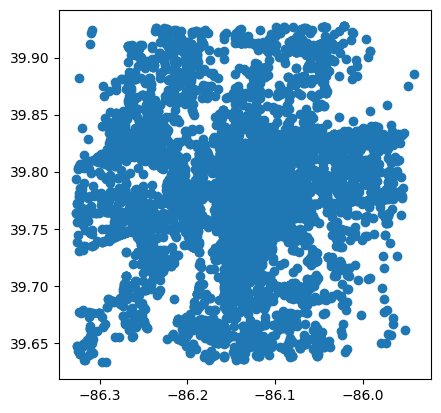

In [7]:
print(len(crime))
display(crime.head())
print(crime.geometry)
crime.plot()

Now we're going to load our Census API key so we can access some Census data!

The code I'm using below is just accessing the raw Census API, but there are a number of Python libraries that attempt to make this "easier" for you. I'm sorry I'm old and this is the way I like best so I'm inflicting it upon you.

In [8]:
#sometimes an API requires an access key
#here's an example oh how to get Census ACS 5-yr data via the API
#and more info on the various APIs https://www.census.gov/data/developers/data-sets/acs-5year.html
#NOTE: different tables (detailed, subject, etc) have different geography levels available
def get_census_data(year,var_str,rename_cols):
    data_url = f'https://api.census.gov/data/{str(year)}/acs/acs5/subject?get={var_str}&for=tract:*&in=state:18%20county:097&key={MYKEY}'
    df = pd.read_json(data_url)
    new_header = df.iloc[0] #grab the first row for the header
    df = df[1:] #take the data less the header row
    df.columns = new_header #set the header row as the df header
    df.rename(columns=rename_cols, inplace=True) #heres where we actually rename
    
    return df

MYKEY = os.environ['census_api_key']

rename_cols = {
    'S0101_C01_001E':'pop',
    'S1901_C01_001E':'households',
    'S1901_C01_012E':'median_income',
    }

var_list = ['GEO_ID','NAME']+list(rename_cols.keys())
var_str = ','.join(var_list)
   
census_df = get_census_data(2024,var_str,rename_cols)

#convert our data columns to numeric
census_df['pop'] = pd.to_numeric(census_df['pop'],errors='coerce')
census_df['households'] = pd.to_numeric(census_df['households'],errors='coerce')
census_df['median_income'] = pd.to_numeric(census_df['median_income'],errors='coerce')

census_df.to_csv(f'../data/analyzed/2024-ACS5yr-indy-in-tract-data.csv',index=False)

If you get the following error:

```
An environment file is configured but terminal environment injection is disabled. Enable "python.terminal.useEnvFile" to use environment variables from .env files in terminals.
```

Go to **Settings > Settings** and search for the word `env`. Under **Extensions > Python environments** you should see an option called Python > Terminal: Use env file. Make sure that is checked.

If you were NOT able to get an API key or if VS Code is being a beezy, you can import the `census_df` data using the codeblock below!

In [9]:
#census_df = pd.read_csv(f'../data/analyzed/2024-ACS5yr-indy-in-tract-data.csv.csv')

In [10]:
#lets check out what we've got
print(census_df.dtypes)
display(census_df.head())

0
GEO_ID             str
NAME               str
pop              int64
households       int64
median_income    int64
state              str
county             str
tract              str
dtype: object


,GEO_ID,NAME,pop,households,median_income,state,county,tract
1,1400000US18097310104,Census Tract 3101.04; Marion County; Indiana,3510,2014,78696,18,097,310104
2,1400000US18097310105,Census Tract 3101.05; Marion County; Indiana,4316,1922,63333,18,097,310105
3,1400000US18097310106,Census Tract 3101.06; Marion County; Indiana,3945,2189,62127,18,097,310106
4,1400000US18097310108,Census Tract 3101.08; Marion County; Indiana,3933,1661,127054,18,097,310108
5,1400000US18097310110,Census Tract 3101.10; Marion County; Indiana,2330,1374,69098,18,097,310110


## Spatial joins and filtering

In [11]:
#filter one dataset by another
crime_in_hoods = gpd.sjoin(crime, hoods, predicate='within')

/var/folders/2g/mqj0d6v95vbfcqgf7kpgrsrc0000gr/T/ipykernel_79167/2867346076.py:2: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:2965

  crime_in_hoods = gpd.sjoin(crime, hoods, predicate='within')


In [12]:
#let's try that again, this time with the correct projections
#remember, gdfs need to be in the same projection for spatial joins
hoods_4326 = hoods.to_crs(epsg=4326)

crime_in_hoods = gpd.sjoin(crime, hoods_4326, predicate='within')

9818
7789


,CaseNum,sOccDate,CR_Desc,Disposition,sCity,sZip,PremiseType,Weapon,NIBRSClassID,NIBRSClassCode,NIBRSClassDesc,NIBRSClassAtt,NIBRSPrimSubCat,NIBRSClassCodeDesc,NIBRSClassIBRcode,NIBRSSubmitted,NIBRSSubDate,CAIU_CrimeAgainst,CAIU_ClassType,CAIU_Rank,CAIU_ClassLabel,CADIncidentType,OccurredFrom,OccurredTo,iOccYr,sOccMn,sOccYrMth,sOccDOW,sOccHr,iOccMth,iOccDOW,Org_area,Org_sector,Geo_Zones,Geo_Districts,Geo_Beats,Geo_Zip,Geo_Council,Geo_Congress,Geo_Precintcts,Geo_Townships,OBJECTID_left,Agency,LocationName,sAddress,AptUnit,CAD,Longitude,Latitude,sOccToDate,iOccToYr,sOccToMth,sOccToYrMth,sOccToDOW,sOccToHr,iOccToMth,iOccToDOW,PublicData,GlobalID,shift,geometry,index_right,OBJECTID_right,NAME,GLOBALID,SHAPESTAre,SHAPESTLen
2000,IP220045108,2022-05-11,Simple Assault,Cleared by Arrest/Summons/UTT/Immediate Detention,IND,46260,"20A - Residence/Home,Garage,Driveway,Yard",NaN,NaN,N13B,Simple Assault,Completed,NaN,N13B - Simple Assault,NaN,NaN,NaT,NaN,Other,NaN,NaN,Domest - Domestic Disturbance,1652310780000,NaN,2022,May,202205,Wednesday,23,5,4,NaN,NaN,ND75,Northwest,NW81,46260,1,NaN,NaN,NaN,2485,IMPD,NaN,2000 BLOCK STONEHAM DR,Apt B,IP22051100002713,-86.196624,39.889262,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,{DE05BB0C-5701-4539-8CF3-B7728FCA7314},3,POINT (-86.19662 39.88926),22,23,Crooked Creek,{DF37F4AC-23B5-44BF-8490-5EC0210EBD16},9.867678e+07,51207.679047
2001,IP220045239,2022-04-01,Destruction/Damage/Vandalism Of Property,Exceptionally Cleared,IND,46241,"20A - Residence/Home,Garage,Driveway,Yard",NaN,NaN,N290,Vandalism Over $2500 Or Hate Crime,Completed,NaN,N290 - Vandalism Over $2500 OR Hate Crime,NaN,NaN,NaT,NaN,Other,NaN,NaN,Trafinv-Traffic Investigation,1648855260000,NaN,2022,April,202204,Friday,23,4,6,NaN,NaN,SW75,Southwest,SW41,46241,20,NaN,NaN,NaN,2486,IMPD,ROLL CALL MSW,3000 BLOCK FOLTZ ST,NaN,IP22051200000849,-86.229897,39.720406,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,{8D37F93D-BC72-49F0-980A-5A054245EC49},3,POINT (-86.2299 39.72041),92,93,Mars Hill,{78DAEF5D-2138-4512-AE48-9E126FCBCDDE},1.742815e+08,63498.042886
2002,IP210035163,2021-04-10,Harassment,Active- Open,IND,46241,13 - Highway/Road/Alley/Street/Sidewalk,NaN,NaN,N90Z09,Harassment,Completed,NaN,N90Z09 - Harassment,NaN,NaN,NaT,NaN,Other,NaN,NaN,Distur - Disturbance,1618068900000,NaN,2021,April,202104,Saturday,15,4,7,NaN,NaN,SW60,Southwest,SW31,46241,22,NaN,NaN,NaN,2487,IMPD,LYNHURST BAPTIST CHURCH,700 BLOCK S LYNHURST DR,NaN,IP21041000001559,-86.250245,39.756401,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,{AE24F245-8FF3-447E-89DF-B23642FB7693},2,POINT (-86.25025 39.7564),49,50,Garden City,{0C0140AD-632F-417F-849C-2A5D6F31D289},1.053957e+08,46714.035058
2003,IP210066154,2021-07-01,Destruction/Damage/Vandalism Of Property,Active- Open,IND,46256,53 - School-Elementary/Secondary,NaN,NaN,AN290,Vandalism Under $2500 No Hate Crime,NaN,NaN,AN290 - Vandalism Under $2500 NO Hate Crime,NaN,NaN,NaT,NaN,Other,NaN,NaN,Invest - Investigation,1625097660000,NaN,2021,July,202107,Thursday,00,7,5,NaN,NaN,ND70,North,ND53,46240,2,NaN,NaN,NaN,2488,WTPD,H DEAN EVANS COMMUNITY AND EDUCATION CENTER,8500 BLOCK WOODFIELD CROSSING BLVD,NaN,IP21070100000640,-86.122405,39.910738,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,{3CF9B3C8-C27D-4E35-A337-94F9E6407F64},3,POINT (-86.1224 39.91074),13,14,North Central,{78CBFFE8-B202-4481-9165-D88197249B5D},5.407808e+07,47734.787177
2004,IP210003927,2021-01-07,False Pretenses/Swindle/Confidence Game,Active- Open,IND,46201,"20A - Residence/Home,Garage,Driveway,Yard",NaN,NaN,N26A,Fraud-Other,Completed,NaN,N26A - Fraud-Other,NaN,NaN,NaT,NaN,Other,NaN,NaN,Fraud - Fraud Investigation,1610020800000,NaN,2021,January,202101,Thursday,12,1,5,NaN,NaN,NE26,East,ED14,46201,12,NaN,NaN,NaN,2489,IMPD,NaN,34200 BLOCK 10TH ST,NaN,IP21011200001137,-86.139724,39.821746,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,{127DCE65-AFD4-41C5-AC8D-CC2CAF55321B},1,POINT (-86.13972 39.82175),43,44,Mapleton / Fall Creek,{F3AA5490-DF55-4338-A40C-9CD2A73D9DD9},3.136767e+07,25987.562117


<Axes: >

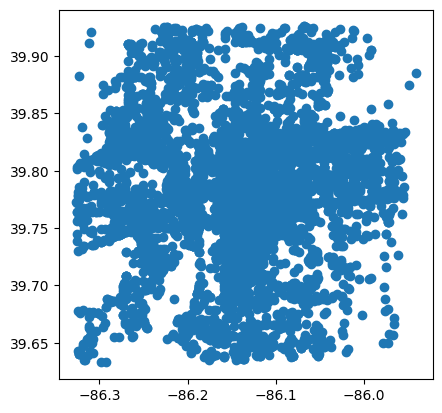

In [13]:
print(len(crime))
print(len(crime_in_hoods))
display(crime_in_hoods.head())
crime_in_hoods.plot()

## Count points in polygon
My fav way to do a point in polygon is to combine a spatial join and a groupby. First, the spatial join lets us connect a neighborhood name with each crime, next, the groupby will let us count the crimes present in each neighborhood. 

In [14]:
#include parameter dropna=False to keep see how many potholes are outside of a neighborhood
crimes_per_hood = crime_in_hoods.groupby('NAME',dropna=False).size().reset_index(name='crimes')

#if we wanna see the top 5 we need to remember to sort_values
crimes_per_hood.sort_values('crimes',ascending=False).head()

,NAME,crimes
25,Downtown,630
63,Near Eastside,608
33,Far Eastside,307
68,Near Westside,274
14,Christian Park,231


In [15]:
#if we feel like knowing more about the types of crimes in each hood, we can do a pivot_table instead
crimes_by_hood_type = pd.pivot_table(crime_in_hoods, index='NAME',columns='CR_Desc',
                                       values='CaseNum',aggfunc='count',fill_value=0)

#and let's add a total column
crimes_by_hood_type['total'] = crimes_by_hood_type.sum(axis=1)

# #and display sorted by total
# crimes_by_hood_type.sort_values('total',ascending=False).head()

In [16]:
crimes_by_hood_type.sort_values('total',ascending=False).head()

CR_Desc,Abandoned Vehicle,Accidental Discharge Of Firearm,Aggravated Assault,All Other Larceny,All Other Non-Criminal Incidents,Animal Cruelty,Animal Destruction,Animal Offense-Non-Cruelty,Arson,Bad Checks,Burglary/Breaking And Entering,Counterfeiting/Forgery,Crash Investigation,Credit Card/Automatic Teller Machine Fraud,Criminal Recklessness,Death Investigation- Body Found,Destruction/Damage/Vandalism Of Property,Disorderly Conduct,Driving Under The Influence,Drug Equipment Violations,Drug/Narcotic Violations,Drunkenness,Embezzlement,Extortion/Blackmail,False Pretenses/Swindle/Confidence Game,Fatality Crash,Fire- Accidental,Fire- Undetermined,Forfeiture,Found/Recovered Property,Fraud-Welfare,From Coin/Operated Machine Or Device,Hacking/Computer Invasion,Harassment,Hit And Run Crash,Identity Theft,Impersonation,Interfere/Inhibit Public Safety/Investigation,Intimidation,Justifiable Homicide,Kidnapping/Abduction,Lost City Property,Lost Property,Maintaining/Visiting Common Nuisance,Missing Person,Money Laundering,Motor Vehicle Conversion,Motor Vehicle Theft,Murder And Nonnegligent Manslaughter,Negligent Manslaughter,Other Jurisdiction Warrant,Pocket/Picking,Pornography/Obscene Material,Probation/Parole/Court Order Violation,Profession/Occupation Violation,Property Damage (Non-Criminal Event),Purchasing Prostitution,Purse-Snatching,Restraining/Protective/No Contact Order Violation,Robbery,Search Warrant Service,Sex Offender Violation,Shoplifting,Simple Assault,Stolen Property Offenses,Theft From Building,Theft From Motor Vehicle,Theft Of Motor Vehicle Parts Or Accessories,Traffic Arrest,Trespass Of Real Property,Unfounded Offense,Warrant-Fta/Bench/Civil/Pre-P1,"Watercraft, Dnr, Environmental Violation",Weapon Law Violations,Wire Fraud,total
NAME,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Downtown,1,0,13,29,24,0,0,1,1,0,7,2,10,5,0,2,34,16,9,3,23,5,0,0,4,0,0,0,0,24,0,1,0,17,33,5,1,1,11,0,0,3,12,0,1,0,0,21,0,0,18,3,0,0,0,8,0,1,0,11,1,1,8,34,2,16,54,6,9,22,8,102,0,5,2,630
Near Eastside,1,1,45,28,25,0,0,0,1,0,30,2,1,3,1,6,39,2,7,1,11,1,1,0,12,0,1,5,0,4,0,0,0,19,46,5,0,1,14,0,1,0,6,1,7,0,1,29,1,0,6,0,1,1,0,8,1,1,4,16,0,0,12,56,6,17,31,13,6,13,5,38,0,12,2,608
Far Eastside,2,0,24,19,11,0,0,0,0,0,18,0,3,1,0,4,31,4,4,0,5,1,1,0,2,0,1,0,0,3,1,0,0,16,17,3,0,1,2,0,1,0,3,0,3,0,0,14,1,0,3,1,0,0,0,5,0,1,3,9,0,0,5,25,3,11,19,4,0,3,3,7,0,9,0,307
Near Westside,1,0,18,9,10,1,0,0,2,0,11,0,3,6,0,2,21,0,2,1,8,0,0,0,4,0,1,2,0,5,0,0,0,8,12,1,0,3,10,0,0,1,6,0,3,0,0,18,1,0,3,1,0,0,0,1,0,0,1,2,1,0,5,33,5,4,14,5,3,3,4,12,0,7,0,274
Christian Park,0,0,8,10,12,0,0,0,0,0,8,1,3,1,0,1,4,1,3,0,1,3,0,0,1,0,0,0,0,3,0,0,0,2,11,1,0,0,1,0,0,1,1,0,3,0,0,3,0,0,2,1,0,0,0,0,0,0,2,1,0,0,6,22,2,0,5,2,6,3,3,90,0,3,0,231


## Crosswalks
Generally, demographic data like population and median income isn't calculated for custom geographies like neighborhoods. But no matter! We can calculate that sort of information for ourselves using crosswalks.

In this example, we are going to cross Census tracts with Indy neighborhoods.

Cam is going to take a minute and talk about why, in the wild, we might want to use block groups instead of tracts. Note that some of the Census data tables are only available at the tract level.

In [17]:
#####################
# Add census data to the tracts
#####################

#make sure we can join on the GEOID cols
census_df['GEOID'] = census_df['GEO_ID'].str.replace('1400000US','')

#join
tracts_data = tracts.merge(census_df, on='GEOID', how='left')
print(len(tracts_data.loc[~tracts_data['pop'].isnull()]))

#we need to make sure both gdfs are in the same projection, but unlike the spatial join
#we need to make sure that projection uses meters or feet because we'll be calculating area
#this projection is specific to the Twin Cities area: https://epsg.io/2965
tracts_data = tracts_data.to_crs(epsg=2965)
hoods = hoods.to_crs(epsg=2965)

#and we'll need to calculate the area of the tracts before and after we do the intersection so we can
#calculate the actual estimated count of people of different races in each tract segmemt.
tracts_data['pre_area'] = tracts_data['geometry'].area

#now let's do that intersection!
tracts_hoods = gpd.overlay(tracts_data, hoods, how='intersection')

#and calculate the area post intersection.  
tracts_hoods['post_area'] = tracts_hoods['geometry'].area

#from the pre and post area calculations we create a percentage
tracts_hoods['pct_area'] = tracts_hoods['post_area']/tracts_hoods['pre_area']

#and then we multiply our tract data counts by that percentage
#to get estimates per segments of the tract that falls within each hood
tracts_hoods['post_pop'] = tracts_hoods['pop'] * tracts_hoods['pct_area']
tracts_hoods['post_households'] = tracts_hoods['households'] * tracts_hoods['pct_area']
tracts_hoods['post_income'] = tracts_hoods['median_income'] * tracts_hoods['pct_area']

#groupby the neighborhood name so we can join back to our neighborhood shapes
hoods_data = tracts_hoods.groupby('NAME').agg({'post_pop':'sum',
                                                'post_households':'sum',
                                                'post_income':'mean'
                                                }).reset_index()

253


In [18]:
hoods_data.head()

,NAME,post_pop,post_households,post_income
0,Acton,3448.784330,1157.038531,5.613056e+04
1,Airport,3536.631012,1289.230362,-1.331252e+08
2,Allisonville,9833.471654,4623.921274,3.368374e+04
3,Ameriplex,5843.924522,1885.054079,1.525441e+04
4,Arlington Woods,9848.904664,4230.146253,1.045989e+04


## Buffers
Now, let's work with our schools and toxic release inventory data! I think it would be interesting to know which schools have a facility that releases toxic air or water chemicals near it. Shall we say 1 mile? If this were for an actual story, we would talk to an expert in the field to figure out the best distance to use.

Cam is gonna talk about finding experts to help inform your geographic analysis.

In [19]:
#first, we have to change the projection to get it into feet
schools = schools.to_crs(epsg=2965)

# Next, we draw a 1 mile buffer around each of our schools. The buffer distance depends on 
# the units of the CRS. Since our CRS is in feet, we need to convert 1 mile to feet.
schools['buffer'] = schools.buffer(5280)

In [20]:
#if we inspect at this point, we can see we've added a new geometry column to our schools gdf
schools.head()

,OBJECTID,NCESSCH,LEAID,NAME,OPSTFIPS,STREET,CITY,STATE,ZIP,STFIP,CNTY,NMCNTY,LOCALE,LAT,LON,CBSA,NMCBSA,CBSATYPE,CSA,NMCSA,CD,SLDL,SLDU,SCHOOLYEAR,geometry,buffer
0,31784,180000802090,1800008,White River Valley Elementary Sch,18,484 W Main St,Worthington,IN,47471,18,18055,Greene County,42,39.119400,-86.986200,N,N,0,N,N,1808,18045,18039,2024-2025,POINT (-46300.241 1412662.46),"POLYGON ((-41020.241 1412662.46, -41045.665 14..."
1,31785,180000802302,1800008,White River Valley High School,18,5644 W SR 54,Switz City,IN,47465,18,18055,Greene County,42,39.035700,-87.047100,N,N,0,N,N,1808,18045,18039,2024-2025,POINT (-64042.831 1382432.667),"POLYGON ((-58762.831 1382432.667, -58788.255 1..."
2,31786,180000802304,1800008,White River Valley Middle School,18,2926 S SR 67,Lyons,IN,47443,18,18055,Greene County,42,38.978051,-87.100439,N,N,0,N,N,1808,18045,18039,2024-2025,POINT (-79525.761 1361669.26),"POLYGON ((-74245.761 1361669.26, -74271.186 13..."
3,31787,180000900115,1800009,Blue River Career Programs,18,801 St. Joseph Street,Shelbyville,IN,46176,18,18145,Shelby County,32,39.511431,-85.788646,26900,"Indianapolis-Carmel-Greenwood, IN",1,294,"Indianapolis-Carmel-Muncie, IN",1806,18073,18028,2024-2025,POINT (293668.072 1552755.296),"POLYGON ((298948.072 1552755.296, 298922.647 1..."
4,31788,180001002628,1800010,Greater Randolph Interlocal Coop,18,325 S Oak St - Suite 301,Winchester,IN,47394,18,18135,Randolph County,32,40.169441,-84.972984,N,N,0,N,N,1803,18033,18026,2024-2025,POINT (521940.689 1793178.299),"POLYGON ((527220.689 1793178.299, 527195.265 1..."


<Axes: >

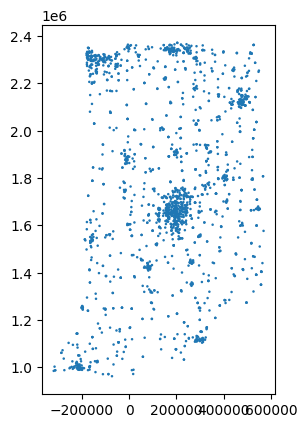

In [21]:
#let's make a school_buffers dataframe separate from our schools dataframe
school_buffers = schools.copy()

#and keep only the columns we need
keep_cols = ['NCESSCH','NAME','CITY','ZIP','NMCNTY','NMCBSA','buffer']
school_buffers = school_buffers[keep_cols]

#and set the geometry to the buffer
school_buffers.set_geometry('buffer',inplace=True)

#and we can plot it
school_buffers.plot()

In [ ]:
#we're going to group the TRI by facility because with this dataset, a single facility will have 
#many rows, one for each chemical released
unique_tri = tri.groupby(['2. TRIFD','4. FACILITY NAME',
                          '5. STREET ADDRESS','6. CITY',
                          '7. COUNTY','geometry']).size().reset_index(name='chemicals_released')

#when we do the groupby, it stops being a geodataframe, so we need to make it one again
#make sure you set the crs. in this case, since we have points, we're setting to the normal lat/lon projection
unique_tri = gpd.GeoDataFrame(unique_tri, geometry='geometry', crs=4326)

unique_tri.head()

,2. TRIFD,4. FACILITY NAME,5. STREET ADDRESS,6. CITY,7. COUNTY,geometry,chemicals_released
0,2623WNLSTL999EA,O'NEAL MANUFACTURING SERVICES,9990 EAST 56TH STREET,INDIANAPOLIS,MARION,POINT (236830.675 1678316.732),1
1,4600WPTBRF13179,POET BIOREFINING ALEXANDRIA LLC,13179 N 100 E,ALEXANDRIA,MADISON,POINT (331934.344 1838173.338),5
2,46015BSTVR722BR,BEST-EVER DAIRY PRODUCTS,722 BROADWAY,ANDERSON,MADISON,POINT (324819.061 1774746.496),1
3,46016GNRLM2915P,SIRMAX N.A. INC,2915 DR MARTIN LUTHER KING JR BLVD,ANDERSON,MADISON,POINT (319006.17 1762750.72),1
4,4601WGRNVL3511W,MORIROKU TECHNOLOGY N.A. - A,3511 W 73RD ST,ANDERSON,MADISON,POINT (310253.289 1745417.992),1


In [ ]:
# change the crs to of our tri to match the school buffers
unique_tri = unique_tri.to_crs(epsg=2965)

#and now the spatial join
tri_schools = gpd.sjoin(unique_tri, school_buffers, predicate='within')

#and we can see how many facilities are within a mile of a school
print(len(tri))
print(len(tri_schools))
display(tri_schools.head())

3211
923


,2. TRIFD,4. FACILITY NAME,5. STREET ADDRESS,6. CITY,7. COUNTY,geometry,chemicals_released,index_right,NCESSCH,NAME,CITY,ZIP,NMCNTY,NMCBSA
0,2623WNLSTL999EA,O'NEAL MANUFACTURING SERVICES,9990 EAST 56TH STREET,INDIANAPOLIS,MARION,POINT (236830.675 1678316.732),1,964,180567000139,Fall Creek Valley Middle School,Indianapolis,46236,Marion County,"Indianapolis-Carmel-Greenwood, IN"
0,2623WNLSTL999EA,O'NEAL MANUFACTURING SERVICES,9990 EAST 56TH STREET,INDIANAPOLIS,MARION,POINT (236830.675 1678316.732),1,979,180567002278,Indian Creek Elementary School,Indianapolis,46236,Marion County,"Indianapolis-Carmel-Greenwood, IN"
3,46016GNRLM2915P,SIRMAX N.A. INC,2915 DR MARTIN LUTHER KING JR BLVD,ANDERSON,MADISON,POINT (319006.17 1762750.72),1,51,180007702425,Anderson Preparatory Academy,Anderson,46016,Madison County,"Indianapolis-Carmel-Greenwood, IN"
3,46016GNRLM2915P,SIRMAX N.A. INC,2915 DR MARTIN LUTHER KING JR BLVD,ANDERSON,MADISON,POINT (319006.17 1762750.72),1,97,180015001847,Anderson Elementary School,Anderson,46011,Madison County,"Indianapolis-Carmel-Greenwood, IN"
6,46032CHMST12236,CHEMSTATION OF INDIANA,12236 HANCOCK ST,CARMEL,HAMILTON,POINT (192865.338 1718574.729),2,304,180120000194,Carmel Middle School,Carmel,46032,Hamilton County,"Indianapolis-Carmel-Greenwood, IN"


If you're asking yourself "Why are there some schools in there more than once!?". It's because some schools have more than one facility within one mile of them. Le YIPE! 

But we know how to deal with that, right? We can groupby the school and count the facilities!

In [24]:
#groupby the school and count the facilities
tri_per_school = tri_schools.groupby(['NAME','CITY','NMCNTY']).size().reset_index(name='tri_facilities')

tri_per_school.sort_values('tri_facilities',ascending=False).head()

,NAME,CITY,NMCNTY,tri_facilities
131,Elkhart Area Career Center,Elkhart,Elkhart County,12
132,Elkhart High School,Elkhart,Elkhart County,11
43,Bremen Elementary/Middle School,Bremen,Marshall County,10
493,Woodland Elementary School,Elkhart,Elkhart County,9
44,Bremen Senior High School,Bremen,Marshall County,7


## Calculating distance
So now we know which schools are within a mile of a TRI facility... but what if I wanted to know about the school with the closest TRI facility? Or maybe calculate all of the distances between schools and their closes TRI facility?

In [29]:
# make sure both of our gdfs are in the same projection AND that that projection uses feet
print(schools.crs)
print(unique_tri.crs)

#geopandas as a lovely function called sjoin_nearest that will do exactly what we want
closest_tri_school = gpd.sjoin_nearest(schools, unique_tri, max_distance=5280, distance_col='distance')

EPSG:2965
EPSG:2965


In [30]:
print(len(schools))
print(len(tri))
print(len(closest_tri_school))

1928
3211
503


In [31]:
closest_tri_school.head()

,OBJECTID,NCESSCH,LEAID,NAME,OPSTFIPS,STREET,CITY,STATE,ZIP,STFIP,CNTY,NMCNTY,LOCALE,LAT,LON,CBSA,NMCBSA,CBSATYPE,CSA,NMCSA,CD,SLDL,SLDU,SCHOOLYEAR,geometry,buffer,index_right,2. TRIFD,4. FACILITY NAME,5. STREET ADDRESS,6. CITY,7. COUNTY,chemicals_released,distance
4,31788,180001002628,1800010,Greater Randolph Interlocal Coop,18,325 S Oak St - Suite 301,Winchester,IN,47394,18,18135,Randolph County,32,40.169441,-84.972984,N,N,0,N,N,1803,18033,18026,2024-2025,POINT (521940.689 1793178.299),"POLYGON ((527220.689 1793178.299, 527195.265 1...",748,4739WSLVRTUNINC,SILVERTOWNE,950 E BASE RD,WINCHESTER,RANDOLPH,1,3043.962429
9,31793,180001602313,1800016,Options Noblesville,18,9945 Cumberland Pointe Blvd,Noblesville,IN,46060,18,18057,Hamilton County,21,40.014990,-85.992031,26900,"Indianapolis-Carmel-Greenwood, IN",1,294,"Indianapolis-Carmel-Muncie, IN",1805,18029,18020,2024-2025,POINT (236951.169 1736324.298),"POLYGON ((242231.169 1736324.298, 242205.744 1...",27,4606WNDSTR15389,INDUSTRIAL DIELECTRICS INC. DBA IDI COMPOSITES...,15389 N POINTE BLVD,NOBLESVILLE,HAMILTON,2,3279.770511
10,31794,180001602700,1800016,Options Indiana,18,18077 River Rd,Noblesville,IN,46062,18,18057,Hamilton County,21,40.050370,-86.029081,26900,"Indianapolis-Carmel-Greenwood, IN",1,294,"Indianapolis-Carmel-Muncie, IN",1805,18029,18020,2024-2025,POINT (226626.15 1749252.479),"POLYGON ((231906.15 1749252.479, 231880.725 17...",23,46060NDSTR407S7,INDUSTRIAL DIELECTRICS INC.,407 S 7TH ST,NOBLESVILLE,HAMILTON,2,4809.604202
11,31795,180001801789,1800018,Christel House Academy South,18,2717 S East St,Indianapolis,IN,46225,18,18097,Marion County,11,39.727941,-86.148329,26900,"Indianapolis-Carmel-Greenwood, IN",1,294,"Indianapolis-Carmel-Muncie, IN",1807,18097,18046,2024-2025,POINT (192609.571 1631959.719),"POLYGON ((197889.571 1631959.719, 197864.146 1...",86,46203SCHST901ET,OLDCASTLE APG - INDIANAPOLIS,901 E TROY AVE,INDIANAPOLIS,MARION,1,2256.193307
12,31796,180001802730,1800018,Christel House Watanabe Manual High School,18,2405 Madison Ave,Indianapolis,IN,46225,18,18097,Marion County,11,39.733596,-86.153364,26900,"Indianapolis-Carmel-Greenwood, IN",1,294,"Indianapolis-Carmel-Muncie, IN",1807,18097,18046,2024-2025,POINT (191204.59 1634027.256),"POLYGON ((196484.59 1634027.256, 196459.166 16...",108,46222RFBDV604EL,AEROFAB,604 E LEGRANDE AVE,INDIANAPOLIS,MARION,1,2706.043781


## Exporting for viz

In [33]:
import folium

In [ ]:
school_tri_map = folium.Map(location = [closest_tri_school['LAT'].mean(), closest_tri_school['LON'].mean()], 
                    zoom_start = 6.2, control_scale = True)

# Render via external HTML to avoid notebook trust/sanitization issues with inline Folium JS
school_tri_map.save('school_tri_map.html')
from IPython.display import IFrame
IFrame(src='school_tri_map.html', width='100%', height=600)
